In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx

import AttackerGNN.MainAttack
import config
import os

import numpy as np

from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)
import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

%cd {config.PROJECT_DIR}

'''%load_ext autoreload
%autoreload 2'''

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[06/17/26 04:58:17] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=661714;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=309395;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[06/17/26 04:58:17] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=241271;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=604453;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

E:\Masterarbeit\AttackerGNN
cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json does not exist.
cache/evasion_global_attr.json does not exist.
cache/evasion_global_adj/evasion_global_adj_1.pt does not exist.
cache/evasion_global_attr/evasion_global_attr_1.pt does not exist.


E:\Anaconda\envs\Masterarbeit\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'
SEED = 0
TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = False
N_PRBCD_RUNS = 3
MINER = 'lrbcd'  # 'lrbcd' or 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None  # e.g. 0.9 to cap top-10% hubs
PRBCD_BUDGET_FRACTION = 0.5
PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05  # each subset = round(fraction × n_candidates)

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
BALANCE_RATIO = 1.0  # neg:pos ratio for zero-label undersampling

[06/17/26 04:58:17] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=169167;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=137548;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

                    INFO     Using custom random split ratios: (0.15, 0.1, 0.3)             ]8;id=933912;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=80681;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#195\195]8;;\

                    INFO     Unused node count: 1264                                        ]8;id=873540;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=442259;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#205\205]8;;\

                    INFO     Training set size: 422                                         ]8;id=542811;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=770135;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 281                                       ]8;id=665122;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=248464;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

...

[06/17/26 04:58:30] INFO                                                                                ]8;id=188991;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=570984;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  500: loss_train: 0.11823, loss_val: 0.41804, acc_train: 0.98341,               
                             acc_val: 0.85765                                                                      

[06/17/26 04:58:33] INFO                                                                                ]8;id=301885;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=874614;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  600: loss_train: 0.11827, loss_val: 0.43936, acc_train: 0.98815,               
                             acc_val: 0.85765                                                                      

[06/17/26 04:58:36] INFO     Test accuracy is 0.8564649820327759 with seed 0                ]8;id=999572;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=804587;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 2856605119760 acquired on cache\demo_custom_split.json.lock       ]8;id=769992;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=215700;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2856605119760 released on cache\demo_custom_split.json.lock       ]8;id=357908;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=390855;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

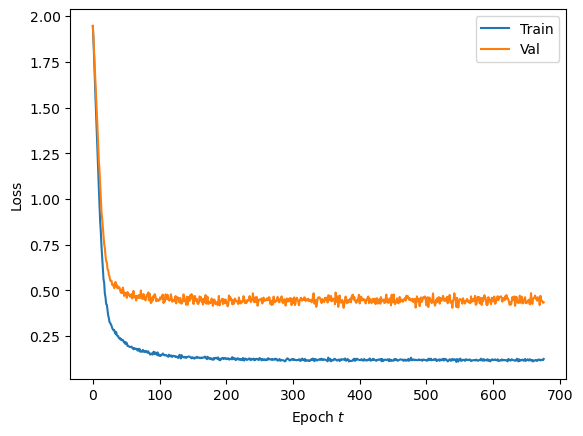

Accuracy of the model: 85.65%


GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)

In [3]:
import torch

train_statistics = experiment_train.run(
    data_dir='./data',
    dataset=DATASET,
    model_params=dict(
        label=MODEL_LABEL,
        model=MODEL_NAME,
        do_cache_adj_prep=True,
        n_filters=64,
        dropout=DROPOUT_VICTIM,
        svd_params=None,
        jaccard_params=None,
        gdc_params={"alpha": 0.15, "k": 64},
    ),
    train_params=dict(
        lr=LR_VICTIM,
        weight_decay=WEIGHT_DECAY_VICTIM,
        patience=PATIENCE_VICTIM,
        max_epochs=MAX_EPOCHS_VICTIM,
    ),
    binary_attr=False,
    make_undirected=True,
    seed=SEED,
    artifact_dir='cache',
    model_storage_type='demo_custom_split',
    ppr_cache_params=dict(),
    device="cpu",
    data_device="cpu",
    display_steps=100,
    debug_level="info",
    custom_split_ratios=(TRAIN_RATIO, VAL_RATIO, TEST_RATIO),
)

# plot train and val loss curves
fig, ax = plt.subplots()

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.plot(train_statistics['trace_train'], color=color, label='Train')

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]
ax.plot(train_statistics['trace_val'], color=color, label='Val')
ax.legend()
plt.show()

clean_acc = train_statistics["accuracy"]
print(f'Accuracy of the model: {100*clean_acc:.2f}%')

model = train_statistics["model"]
graph = train_statistics["graph"]
idx_train = train_statistics["idx_train"]
idx_val = train_statistics["idx_val"]
idx_test = train_statistics["idx_test"]
model.eval()

In [4]:
import torch

attr_matrix, adj_matrix, labels_raw = graph[:3]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Display ────────────────────────────────────────────────────────────────
n_nodes = adj_matrix.sizes()[0]
n_edges_directed = adj_matrix.nnz()
n_undirected = n_edges_directed // 2

print(f"nodes={n_nodes}")
print(f"Directed edges: {n_edges_directed}")
print(f"Undirected edges: {n_undirected}")
print(f"features={attr_matrix.shape}")
print(f"classes={len(torch.unique(labels_raw))}")

# ── Convert adjacency SparseTensor -> edge_index / edge_weight ─────────────
row, col, value = adj_matrix.coo()

edge_index = torch.stack([row, col], dim=0).long().to(device)

if value is None:
    edge_weight = torch.ones(edge_index.size(1), dtype=torch.float32, device=device)
else:
    edge_weight = value.float().to(device)

# ── Convert features / labels ──────────────────────────────────────────────
attr = attr_matrix.float().to(device)
labels = labels_raw.long().to(device)

# ── Safety checks ──────────────────────────────────────────────────────────
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)
print("max node id in edge_index:", int(edge_index.max()))
print("n_nodes:", n_nodes)

assert int(edge_index.max()) < n_nodes
assert attr.shape[0] == n_nodes
assert labels.shape[0] == n_nodes
'''
train_idx_np, val_idx_np, test_idx_np = train_val_test_split(
    graph.labels,
    train_size=0.05,
    val_size=0.05,
    test_size=0.9,
    mode="stratified",
    seed=SEED,
)

train_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)
val_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)
test_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'''

nodes=2810
Directed edges: 15962
Undirected edges: 7981
features=torch.Size([2810, 2879])
classes=7
edge_index shape: torch.Size([2, 15962])
edge_weight shape: torch.Size([15962])
max node id in edge_index: 2809
n_nodes: 2810


'\ntrain_idx_np, val_idx_np, test_idx_np = train_val_test_split(\n    graph.labels,\n    train_size=0.05,\n    val_size=0.05,\n    test_size=0.9,\n    mode="stratified",\n    seed=SEED,\n)\n\ntrain_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)\nval_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)\ntest_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'

In [5]:
from helpers.selector_pipeline_helpers import EndpointPRBCDV4Scorer, _edge_set
import random

# ── Candidate sampling ──────────────────────────────────────────────────────
budget = max(1, round(PRBCD_BUDGET_FRACTION * n_undirected))

if USE_PRBCD_CANDIDATES:
    # ── Run endpointPRBCD/V4-style scorer ───────────────────────────────────
    scorer = EndpointPRBCDV4Scorer(
        n=n_nodes,
        edge_index=edge_index,
        edge_weight=edge_weight,
        attr=attr,
        labels=labels,
        attacked_model=model,
        idx_attack=idx_test,
        test_idx=idx_val,
        device=device,
        block_size=PRBCD_SEARCH_SPACE,
        n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,

        n_subsets=N_SUBSETS,
        subset_fraction=SUBSET_FRACTION,
        balance_ratio=BALANCE_RATIO,
        store_candidates=True,
    )

    candidates = scorer.mine_prbcd_endpoint_candidates(
        n_perturbations=budget,
        tag="endpointPRBCD",
        rng_seed=SEED,
        n_candidates=PRBCD_SEARCH_SPACE,
        prbcd_epochs=PRBCD_EPOCHS,
        n_prbcd_runs=N_PRBCD_RUNS,
        n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
    )

else:
    # same candidate count as PRBCD budget over all runs:
    # num_edges * budget_fraction * n_prbcd_runs
    n_random_candidates = max(
        1,
        round(n_undirected * PRBCD_BUDGET_FRACTION * N_PRBCD_RUNS)
    )

    rng = random.Random(SEED)
    candidates_set = set()

    while len(candidates_set) < n_random_candidates:
        u = rng.randrange(n_nodes)
        v = rng.randrange(n_nodes)

        if u == v:
            continue

        candidates_set.add((min(u, v), max(u, v)))

    candidates = list(candidates_set)

# ── Inspect mined / sampled candidates ──────────────────────────────────────
print(f"Candidates: {len(candidates)}")

orig_edges = _edge_set(edge_index)
n_cands    = len(candidates)
n_removals = sum(1 for e in candidates if e in orig_edges)
n_adds     = n_cands - n_removals

print(f"Candidates: {n_cands}  ({n_adds} additions, {n_removals} removals)")
print(f"Original edges: {orig_edges}")

Candidates: 11972
Candidates: 11972  (11956 additions, 16 removals)
Original edges: {(1042, 2704), (1560, 2401), (1656, 2109), (2736, 2741), (571, 2301), (924, 1436), (1106, 1184), (460, 2470), (191, 1787), (1693, 1883), (514, 2706), (2016, 2802), (2773, 2781), (1159, 1195), (2437, 2795), (797, 2240), (1406, 2055), (1072, 2704), (1101, 1190), (1309, 2122), (142, 1787), (264, 464), (1103, 1236), (1308, 1668), (714, 1195), (1115, 2293), (573, 1973), (1404, 2130), (1412, 1991), (1977, 2702), (1532, 1534), (611, 2615), (2015, 2176), (1454, 1614), (1863, 2802), (505, 913), (726, 1555), (731, 2653), (231, 529), (64, 123), (34, 1678), (2116, 2349), (2677, 2682), (510, 1378), (97, 1468), (959, 975), (236, 351), (1368, 1668), (2739, 2742), (984, 1971), (285, 1933), (1189, 2605), (1127, 1727), (270, 349), (498, 1933), (102, 1933), (1893, 1903), (189, 2346), (1195, 2275), (11, 1293), (1592, 1682), (45, 123), (31, 188), (1390, 2487), (719, 2282), (818, 1507), (2248, 2252), (529, 1404), (590, 596),

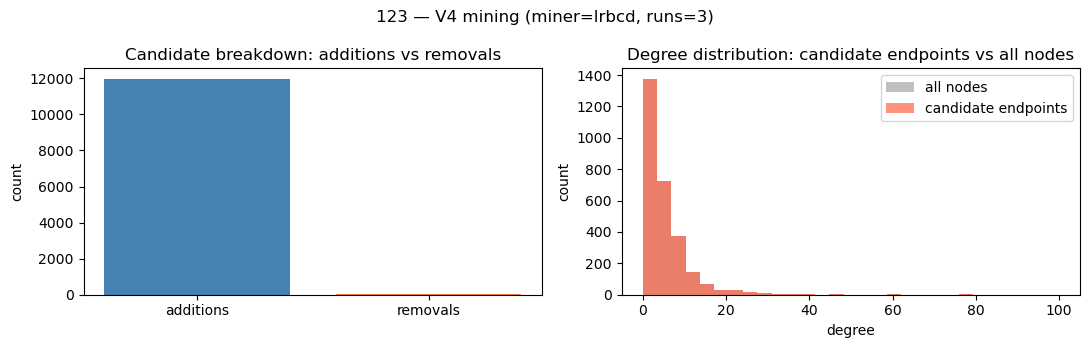

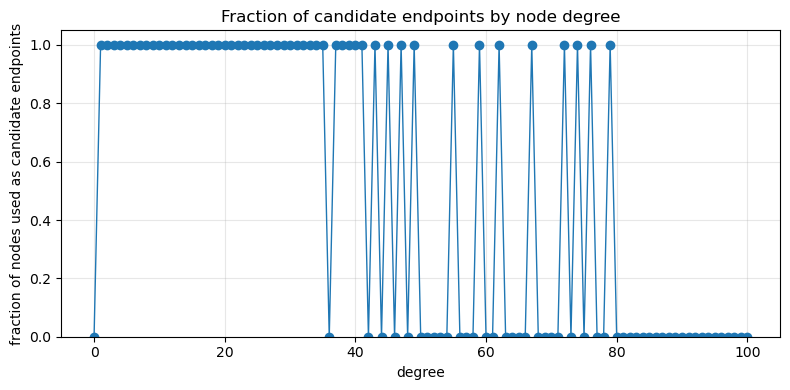

In [6]:
degrees    = np.bincount(edge_index[0].cpu().numpy(), minlength=n_nodes)
cand_nodes = set(u for u, v in candidates) | set(v for u, v in candidates)
cand_degs  = degrees[list(cand_nodes)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(['additions', 'removals'], [n_adds, n_removals], color=['steelblue', 'coral'])
axes[0].set_title('Candidate breakdown: additions vs removals')
axes[0].set_ylabel('count')

bins = np.linspace(0, min(degrees.max(), 100), 30)
axes[1].hist(degrees,     bins=bins, alpha=0.5, label='all nodes',          color='grey')
axes[1].hist(cand_degs,   bins=bins, alpha=0.7, label='candidate endpoints', color='tomato')
axes[1].set_title('Degree distribution: candidate endpoints vs all nodes')
axes[1].set_xlabel('degree'); axes[1].set_ylabel('count'); axes[1].legend()

plt.suptitle(f'{123} — V4 mining (miner={MINER}, runs={N_PRBCD_RUNS})', fontsize=12)
plt.tight_layout()
plt.show()

# Fraction of nodes per degree that appear as candidate endpoints
all_degree_counts = np.bincount(degrees)

candidate_endpoint_mask = np.zeros(n_nodes, dtype=bool)
candidate_endpoint_mask[list(cand_nodes)] = True

candidate_degree_counts = np.bincount(
    degrees[candidate_endpoint_mask],
    minlength=len(all_degree_counts)
)

candidate_fraction_by_degree = np.divide(
    candidate_degree_counts,
    all_degree_counts,
    out=np.zeros_like(candidate_degree_counts, dtype=float),
    where=all_degree_counts > 0
)

# Optional: restrict to visible degree range
max_degree_plot = min(degrees.max(), 100)
degree_values = np.arange(max_degree_plot + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    degree_values,
    candidate_fraction_by_degree[:max_degree_plot + 1],
    marker="o",
    linewidth=1,
)

plt.title("Fraction of candidate endpoints by node degree")
plt.xlabel("degree")
plt.ylabel("fraction of nodes used as candidate endpoints")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print("vor breakpoint")
print("nach breakpoint")

import sys
print(sys.executable)
print(sys.version)

vor breakpoint
nach breakpoint
E:\Anaconda\envs\Masterarbeit\python.exe
3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]


---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool, apply each subset jointly, and measure test-accuracy drop.  Each edge accumulates the drops of every subset it was in; the raw scores are normalised globally to [0, 1].

**Key diagnostics:**
- Accuracy drop per subset — are subsets actually harming the model?
- Distribution of raw accumulated scores — how skewed is it?
- Fraction of candidates with score > 0 — coverage.

In [8]:
from pathlib import Path

from helpers.selector_pipeline_helpers import (
    mine_candidate_edge_scores,
    save_mining_output,
    load_mining_output,
    _dense_adj,
)

adj_orig    = _dense_adj(edge_index, n_nodes, device=device)
cand_src    = [u for u, v in candidates]
cand_dst    = [v for u, v in candidates]
exists_list = [float(adj_orig[u, v].item()) for u, v in candidates]

MINING_MODE = "subset_accuracy_drop"

CACHE_PATH = Path(
    "cache"
) / (
    f"candidate_mining_"
    f"mode-{MINING_MODE}_"
    f"seed-{SEED}_"
    f"candidates-{len(candidates)}.pt"
)

cache_metadata = {
    "mode": MINING_MODE,
    "seed": int(SEED),
    "n_nodes": int(n_nodes),
    "n_candidates": int(len(candidates)),
    "subset_fraction": float(SUBSET_FRACTION),
    "n_subsets": int(N_SUBSETS),
    "endpoint_require_correct_to_incorrect": True,
}


if CACHE_PATH.exists():
    mining_result, cached_candidates, stored_metadata = (
        load_mining_output(
            CACHE_PATH,
            device=device,
            expected_metadata=cache_metadata,
        )
    )

    # Optional additional safety check.
    if cached_candidates != candidates:
        raise ValueError(
            "The candidates in the cache differ from the "
            "current candidates."
        )

else:
    mining_result = mine_candidate_edge_scores(
        model=model,
        attr=attr,
        edge_index=edge_index,
        labels=labels,
        eval_idx=idx_test,
        candidates=candidates,
        n_nodes=n_nodes,
        mode=MINING_MODE,

        subset_fraction=SUBSET_FRACTION,
        n_subsets=N_SUBSETS,

        endpoint_k_samples=None,
        endpoint_require_correct_to_incorrect=True,

        two_hop_k_samples=None,

        seed=SEED,
        device=device,
        verbose=True,
    )

    save_mining_output(
        CACHE_PATH,
        mining_result,
        candidates=candidates,
        metadata=cache_metadata,
    )

labels_raw = mining_result["labels_raw"]
labels_norm = mining_result["labels_norm"]
clean_acc_v = mining_result["clean_accuracy"]

print(f"Clean test accuracy: {clean_acc_v:.4f}")


if MINING_MODE == "subset_accuracy_drop":
    drop_per_subset = mining_result["drop_per_subset"]
    subset_size = mining_result["subset_size"]

    max_raw = (
        float(labels_raw.max())
        if len(labels_raw) > 0
        else 0.0
    )

    n_pos = int((labels_norm > 0).sum())

    print(
        f"Subset size: {subset_size} "
        f"({SUBSET_FRACTION:.0%} of "
        f"{len(candidates)} candidates)"
    )

    print(f"\nSubsets run: {N_SUBSETS}")

    print(
        "Accuracy drop per subset: "
        f"mean={drop_per_subset.mean():.4f}  "
        f"max={drop_per_subset.max():.4f}  "
        f"zero_rate={(drop_per_subset == 0).mean():.2%}"
    )

    print(
        f"Edges with score > 0: "
        f"{n_pos}/{len(candidates)} "
        f"({100 * n_pos / len(candidates):.1f}%)"
    )

    print(
        f"Raw score stats: "
        f"max={max_raw:.4f}  "
        f"mean={labels_raw.mean():.4f}"
    )

elif MINING_MODE == "endpoint":
    endpoint_labels = np.asarray(
        mining_result["endpoint_labels"]
    )

    u_hit_labels = np.asarray(
        mining_result["u_hit_labels"]
    )

    v_hit_labels = np.asarray(
        mining_result["v_hit_labels"]
    )

    both_hit_labels = np.asarray(
        mining_result["both_hit_labels"]
    )

    sampled_edge_index = mining_result[
        "sampled_edge_index"
    ]

    n_selected = int(
        mining_result["n_samples"]
    )

    endpoint_hits = int(
        endpoint_labels.sum()
    )

    u_hits = int(
        u_hit_labels.sum()
    )

    v_hits = int(
        v_hit_labels.sum()
    )

    both_hits = int(
        both_hit_labels.sum()
    )

    n_positive = endpoint_hits

    endpoint_hit_rate = (
        endpoint_hits / n_selected
        if n_selected > 0
        else 0.0
    )

    print(
        f"Original candidate pairs evaluated: "
        f"{n_selected}"
    )

    print(
        f"Endpoint hits: "
        f"{endpoint_hits}/{n_selected} "
        f"({endpoint_hit_rate:.2%})"
    )

    print(
        f"u hits={u_hits}  "
        f"v hits={v_hits}  "
        f"both hits={both_hits}"
    )

    print(
        f"Positive endpoint labels: "
        f"{n_positive}/{n_selected}"
    )

    print(
        f"Candidate edge tensor shape: "
        f"{tuple(sampled_edge_index.shape)}"
    )

    assert sampled_edge_index.ndim == 2
    assert sampled_edge_index.shape[0] == 2
    assert sampled_edge_index.shape[1] == n_selected
    assert endpoint_labels.shape[0] == n_selected
    assert u_hit_labels.shape[0] == n_selected
    assert v_hit_labels.shape[0] == n_selected
    assert both_hit_labels.shape[0] == n_selected


elif MINING_MODE == "two_hop_correct_to_incorrect":
    sampled_edge_index = mining_result["sampled_edge_index"]

    n_samples = mining_result["n_samples"]
    n_unique_candidates = mining_result[
        "n_unique_candidates"
    ]

    positive_flips = mining_result["positive_flips"]

    total_correct_to_incorrect = mining_result[
        "total_correct_to_incorrect"
    ]

    mean_raw_score = mining_result["mean_raw_score"]
    raw_score_min = mining_result["raw_score_min"]
    raw_score_max = mining_result["raw_score_max"]

    mean_neighborhood_size = mining_result[
        "mean_neighborhood_size"
    ]

    neighborhood_sizes = mining_result[
        "neighborhood_sizes"
    ]

    print(
        f"Two-hop candidate edges evaluated: "
        f"{n_samples}/{n_unique_candidates}"
    )

    print(
        f"Flips causing at least one "
        f"correct-to-incorrect transition: "
        f"{positive_flips}/{n_samples} "
        f"({positive_flips / n_samples:.2%})"
    )

    print(
        f"Total correct-to-incorrect transitions: "
        f"{total_correct_to_incorrect}"
    )

    print(
        f"Raw score stats: "
        f"min={raw_score_min:.0f}  "
        f"max={raw_score_max:.0f}  "
        f"mean={mean_raw_score:.4f}"
    )

    print(
        f"Normalized score stats: "
        f"min={labels_norm.min():.4f}  "
        f"max={labels_norm.max():.4f}  "
        f"mean={labels_norm.mean():.4f}"
    )

    print(
        f"Mean two-hop union-neighborhood size: "
        f"{mean_neighborhood_size:.2f}"
    )

    print(
        f"Neighborhood-size range: "
        f"{neighborhood_sizes.min()}–"
        f"{neighborhood_sizes.max()}"
    )

    print(
        f"Sampled edge tensor shape: "
        f"{tuple(sampled_edge_index.shape)}"
    )


else:
    raise ValueError(
        f"Unknown MINING_MODE: {MINING_MODE}"
    )

[MINING CACHE] Loaded mining output from: cache\candidate_mining_mode-subset_accuracy_drop_seed-0_candidates-11972.pt
Clean test accuracy: 0.8565
Subset size: 599 (5% of 11972 candidates)

Subsets run: 1000
Accuracy drop per subset: mean=0.0073  max=0.0249  zero_rate=10.00%
Edges with score > 0: 11972/11972 (100.0%)
Raw score stats: max=0.6489  mean=0.3657


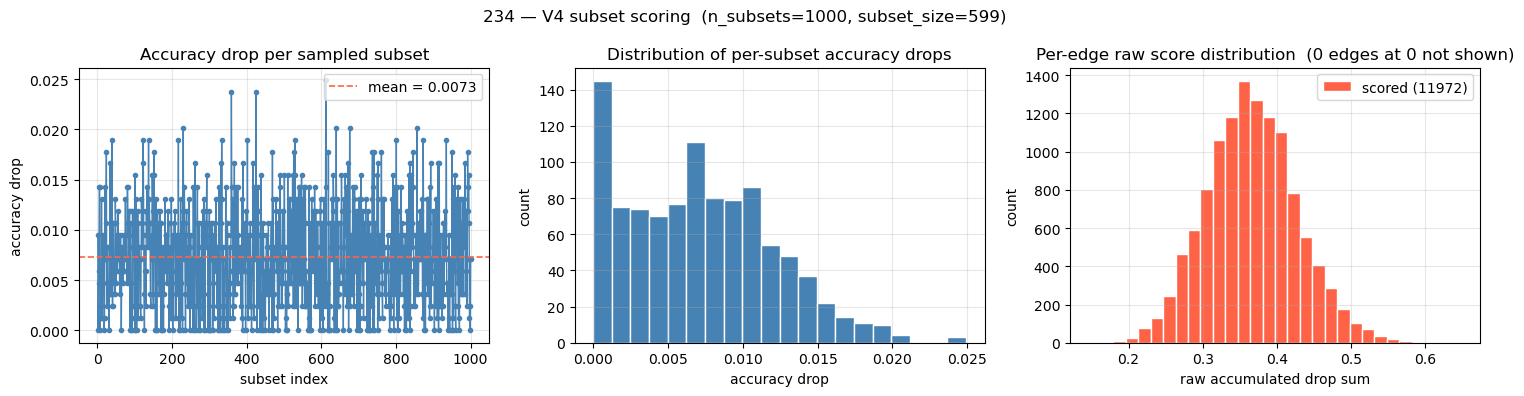

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Drop per subset over time
axes[0].plot(np.arange(1, N_SUBSETS + 1), drop_per_subset,
             marker='o', markersize=3, linewidth=1, color='steelblue')
axes[0].axhline(drop_per_subset.mean(), color='tomato', linestyle='--', linewidth=1.2,
                label=f'mean = {drop_per_subset.mean():.4f}')
axes[0].set_xlabel('subset index'); axes[0].set_ylabel('accuracy drop')
axes[0].set_title('Accuracy drop per sampled subset')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Distribution of accuracy drops
axes[1].hist(drop_per_subset, bins=20, color='steelblue', edgecolor='white')
axes[1].set_xlabel('accuracy drop'); axes[1].set_ylabel('count')
axes[1].set_title('Distribution of per-subset accuracy drops')
axes[1].grid(True, alpha=0.3)

# Distribution of raw edge scores
axes[2].hist(labels_raw[labels_raw > 0], bins=30, color='tomato',
             edgecolor='white', label=f'scored ({n_pos})')
axes[2].set_xlabel('raw accumulated drop sum'); axes[2].set_ylabel('count')
axes[2].set_title(f'Per-edge raw score distribution  ({n_cands - n_pos} edges at 0 not shown)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{234} — V4 subset scoring  (n_subsets={N_SUBSETS}, subset_size={subset_size})', fontsize=12)
plt.tight_layout()
plt.show()

---
## §3  Label Distribution

After global normalisation the labels are continuous in [0, 1].  Unlike V1–V3 (binary 0/1), V4 labels represent a **relative harmfulness score** — the edge with the highest total accumulated accuracy drop receives 1.0.

In [10]:
n_pos = int((labels_norm > 0).sum())

Label stats:
  min=0.2249  mean=0.5636  max=1.0000  std=0.0942
  Fraction with label > 0: 1.000
  Fraction with label > 0.5: 0.748


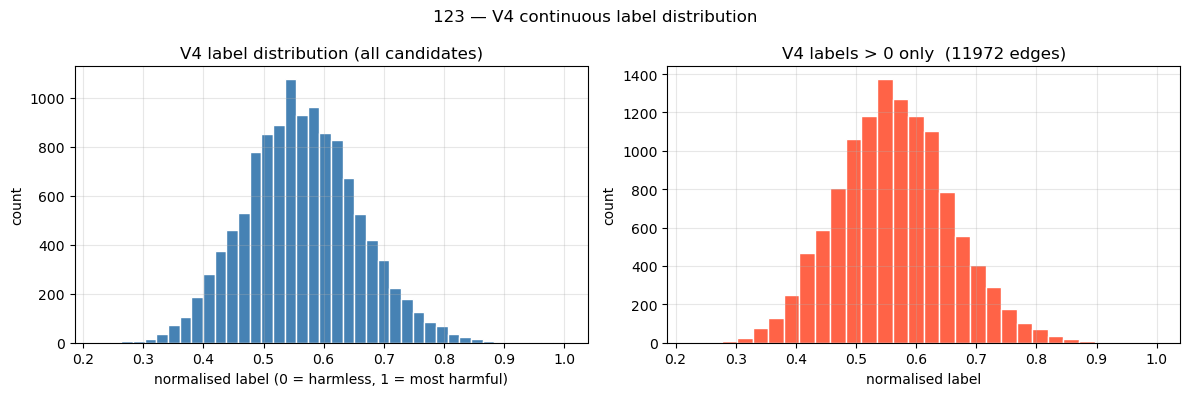

In [11]:
''# Convert to tensors for scorer use
src    = torch.tensor(cand_src,    dtype=torch.long,    device=device)
dst    = torch.tensor(cand_dst,    dtype=torch.long,    device=device)
labels_changed = torch.tensor(labels_norm, dtype=torch.float32, device=device)
exists = torch.tensor(exists_list, dtype=torch.float32, device=device)

print('Label stats:')
print(f'  min={float(labels_changed.min()):.4f}  mean={float(labels_changed.mean()):.4f}  '
      f'max={float(labels_changed.max()):.4f}  std={float(labels_changed.std()):.4f}')
print(f'  Fraction with label > 0: {(labels_changed > 0).float().mean():.3f}')
print(f'  Fraction with label > 0.5: {(labels_changed > 0.5).float().mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lbl_np = labels_changed.cpu().numpy()
axes[0].hist(lbl_np, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('normalised label (0 = harmless, 1 = most harmful)')
axes[0].set_ylabel('count')
axes[0].set_title('V4 label distribution (all candidates)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(lbl_np[lbl_np > 0], bins=30, color='tomato', edgecolor='white')
axes[1].set_xlabel('normalised label')
axes[1].set_ylabel('count')
axes[1].set_title(f'V4 labels > 0 only  ({n_pos} edges)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 continuous label distribution', fontsize=12)
plt.tight_layout()
plt.show()

---
## §4  Oracle Check — Top-Scored vs Random Subsets

Apply the top-k edges by V4 label jointly and compare accuracy with applying k random candidate edges.  If the labels are informative, the top-scored selection should consistently produce larger accuracy drops.

In [12]:
from helpers.selector_pipeline_helpers import accuracy
import pandas as pd

BLOCK_STEP_ORACLE = 10

sort_order = labels_changed.cpu().argsort(descending=True)
print(labels_changed[1])
print(labels_changed[2993])
print(labels_changed[3221])
all_idx = np.arange(n_cands)
block_sizes = list(range(0, n_cands, BLOCK_STEP_ORACLE))
if not block_sizes or block_sizes[-1] != n_cands:
    block_sizes.append(n_cands)

rng_o = np.random.default_rng(42)
rows_o = []

for k in block_sizes:
    # Top-k by V4 label
    adj_top = adj_orig.clone()
    if k > 0:
        for i in sort_order[:k].tolist():
            u, v = cand_src[i], cand_dst[i]
            adj_top[u, v] = 1.0 - exists_list[i]
            adj_top[v, u] = 1.0 - exists_list[i]

    test_acc = accuracy(model, attr, labels, idx_test, edge_index=adj_top)

    rows_o.append({
        'k': k,
        'attack': 'top-k by V4 label',
        'test_accuracy': test_acc
    })

    # Random k from all candidates
    adj_rnd = adj_orig.clone()
    if k > 0:
        for i in rng_o.choice(all_idx, size=min(k, n_cands), replace=False).tolist():
            u, v = cand_src[i], cand_dst[i]
            adj_rnd[u, v] = 1.0 - exists_list[i]
            adj_rnd[v, u] = 1.0 - exists_list[i]

    rows_o.append({
        'k': k,
        'attack': 'random candidates',
        'test_accuracy': accuracy(model, attr, labels, idx_test, edge_index=adj_rnd)
    })

oracle_df = pd.DataFrame(rows_o)
display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').tail(20))

tensor(0.4552)
tensor(0.3803)
tensor(0.6527)


attack,random candidates,top-k by V4 label
k,,
11790,0.784104,0.784104
11800,0.787663,0.784104
11810,0.787663,0.782918
11820,0.787663,0.784104
11830,0.787663,0.784104
11840,0.785291,0.782918
11850,0.788849,0.782918
11860,0.786477,0.784104
11870,0.786477,0.785291


In [13]:
display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').head(20))

attack,random candidates,top-k by V4 label
k,,
0,0.856465,0.856465
10,0.854093,0.857651
20,0.857651,0.855279
30,0.857651,0.852906
40,0.857651,0.851720
50,0.857651,0.850534
60,0.855279,0.849348
70,0.852906,0.848161
80,0.856465,0.846975


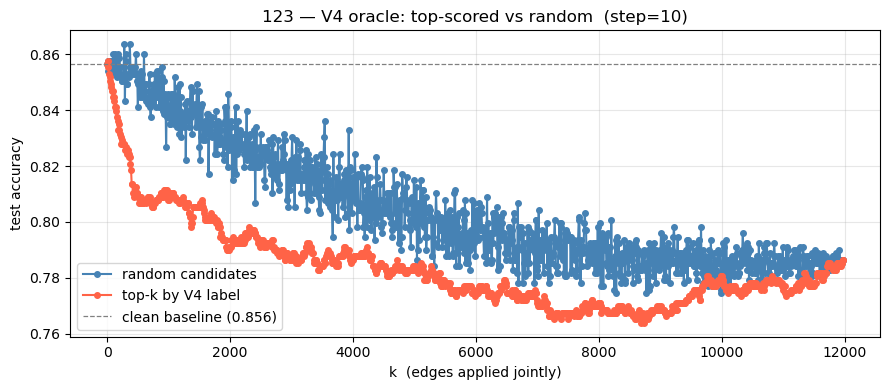

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
for attack, grp in oracle_df.groupby('attack'):
    color = 'tomato' if 'V4' in attack else 'steelblue'
    ax.plot(grp['k'], grp['test_accuracy'], marker='o', markersize=4,
            label=attack, color=color)
ax.axhline(clean_acc, color='grey', linestyle='--', linewidth=0.9,
           label=f'clean baseline ({clean_acc:.3f})')
ax.set_xlabel('k  (edges applied jointly)'); ax.set_ylabel('test accuracy')
ax.set_title(f'{123} — V4 oracle: top-scored vs random  (step={BLOCK_STEP_ORACLE})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
import torch
import torch.nn.functional as F
from helpers.selector_pipeline_helpers import train_link_prediction_gnn

attacker_x = attr  # node features
edge_index_struct = edge_index  # graph structure for message passing

# IMPORTANT:
# use edge/candidate labels here, not node labels
edge_labels = labels_changed  # or labels_norm tensor, depending on your variable name
edge_index_lab = torch.stack([src, dst], dim=0)  # shape: (2, M)

print(edge_labels)

# Optionally apply balance_ratio undersampling
src_bal, dst_bal, lbl_bal, ex_bal = src, dst, edge_labels, exists

if BALANCE_RATIO is not None:
    pos_mask = edge_labels > 0.5
    neg_mask = ~pos_mask

    n_pos_b = int(pos_mask.sum().item())
    n_neg_t = max(1, round(n_pos_b * BALANCE_RATIO))

    if n_neg_t < int(neg_mask.sum().item()):
        g = torch.Generator(device="cpu").manual_seed(SEED)
        neg_idx = neg_mask.nonzero(as_tuple=True)[0]
        perm = torch.randperm(len(neg_idx), generator=g)[:n_neg_t]

        keep = torch.cat([
            pos_mask.nonzero(as_tuple=True)[0],
            neg_idx[perm],
        ])

        src_bal = src[keep]
        dst_bal = dst[keep]
        lbl_bal = edge_labels[keep]
        ex_bal = exists[keep]

    edge_index_bal = torch.stack(
            [src_bal.long(), dst_bal.long()],
            dim=0,
        )

    print(
        f"After balancing: {n_pos_b} scored + {n_neg_t} zero-label "
        f"(ratio 1:{BALANCE_RATIO})"
    )

lp_model = train_link_prediction_gnn(
    x=attacker_x,
    edge_index_struct=edge_index_struct,
    edge_index_lab=edge_index_bal,
    y_label=lbl_bal,
    device=device,
    num_epochs=200,
    hidden_dim=64,
    out_dim=64,
    lr=5e-4,
    weight_decay=5e-4,
    use_tqdm=True,
    verbose=True,

    # Early stopping for imbalanced ranking.
    early_stop=True,
    early_stop_metric="val_ap",
    min_epochs_before_early_stop=100,
    early_stop_patience=15,
    early_stop_min_delta=1e-4,
    restore_best=True,

    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    threshold=0.5,
)

tensor([0.4954, 0.4552, 0.6088,  ..., 0.5631, 0.3967, 0.4479])
After balancing: 8954 scored + 8954 zero-label (ratio 1:1.0)


ValueError: y_label must contain only binary values 0 and 1. Found values: [0.22486253082752228, 0.23217523097991943, 0.23765957355499268, 0.2504562735557556, 0.2504565417766571, 0.27056628465652466, 0.2742224633693695, 0.27605101466178894, 0.277878999710083, 0.27787917852401733, 0.28153517842292786, 0.2851916253566742, 0.2870197892189026, 0.29798904061317444, 0.2998170256614685, 0.30164504051208496, 0.3053012788295746, 0.30712929368019104, 0.30712956190109253, 0.30895745754241943, 0.31078583002090454, 0.31261399388313293, 0.3144422769546509, 0.31626999378204346, 0.3162700831890106, 0.3180985152721405, 0.31992679834365845, 0.321754515171051, 0.3217547833919525, 0.3235826790332794, 0.3235829770565033, 0.32358306646347046, 0.3254108726978302, 0.32541096210479736, 0.3254110515117645, 0.32723894715309143, 0.3272390365600586, 0.3272393047809601, 0.3290669322013855, 0.32906731963157654, 0.33089521527290344, 0.33089539408683777, 0.33089548349380493, 0.33272337913513184, 0.332723468542099, 0.3

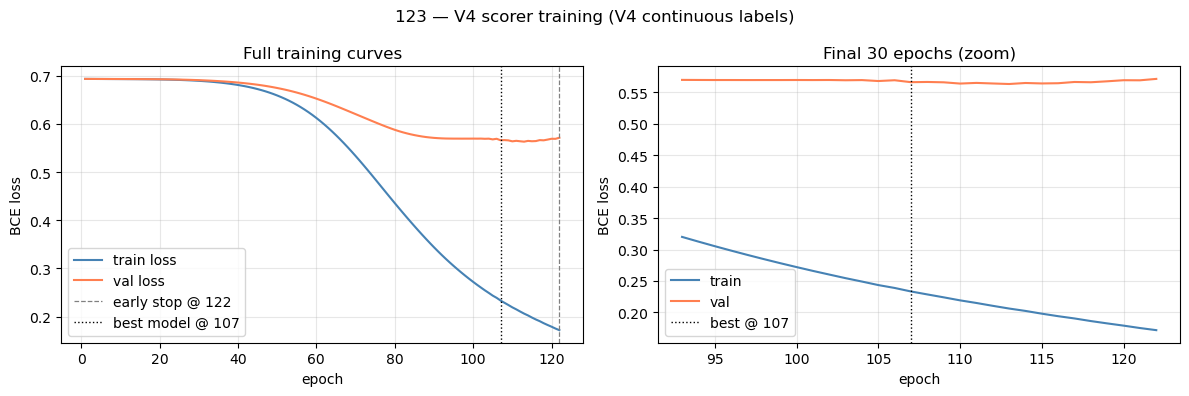

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Use `self.lp_model` inside the PRBCD class/notebook context.
# Replace with `model` when the returned model is stored under another name.
history = lp_model.training_history

train_losses = np.asarray(
    history["train_losses"],
    dtype=float,
)
val_losses = np.asarray(
    history["val_losses"],
    dtype=float,
)

stopped_at = int(history["stopped_at"])
best_epoch = history.get("best_epoch")
early_stopped = bool(history.get("early_stopped", False))

epochs_run = len(train_losses)

if epochs_run == 0:
    raise RuntimeError(
        "No completed training epochs are available for plotting."
    )

if len(val_losses) != epochs_run:
    raise RuntimeError(
        "train_losses and val_losses have different lengths: "
        f"{epochs_run} and {len(val_losses)}."
    )

ep_axis = np.arange(1, epochs_run + 1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

# ==========================================================
# Full training curves
# ==========================================================

axes[0].plot(
    ep_axis,
    train_losses,
    label="train loss",
    color="steelblue",
)

axes[0].plot(
    ep_axis,
    val_losses,
    label="val loss",
    color="coral",
)

stop_label = (
    f"early stop @ {stopped_at}"
    if early_stopped
    else f"training ended @ {stopped_at}"
)

axes[0].axvline(
    stopped_at,
    color="grey",
    linestyle="--",
    linewidth=0.9,
    label=stop_label,
)

if best_epoch is not None:
    axes[0].axvline(
        best_epoch,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label=f"best model @ {best_epoch}",
    )

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Full training curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ==========================================================
# Final epochs
# ==========================================================

z = min(30, epochs_run)

axes[1].plot(
    ep_axis[-z:],
    train_losses[-z:],
    label="train",
    color="steelblue",
)

axes[1].plot(
    ep_axis[-z:],
    val_losses[-z:],
    label="val",
    color="coral",
)

if best_epoch is not None and best_epoch >= ep_axis[-z]:
    axes[1].axvline(
        best_epoch,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label=f"best @ {best_epoch}",
    )

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("BCE loss")
axes[1].set_title(f"Final {z} epochs (zoom)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "123 — V4 scorer training (V4 continuous labels)",
    fontsize=12,
)

plt.tight_layout()
plt.show()

---
## §6  Score Distributions & Ranking Quality

We score every candidate and ask:
- Do edges with V4 label > 0 (appeared in at least one harmful subset) receive higher logits?
- Does the predicted score *correlate* with the true continuous label?
- AUC-ROC (binary: scored vs unscored) and precision@k are computed as proxy metrics.

In [25]:
import torch
import numpy as np

# Your trained LinkPredictionGNN
scorer = lp_model
# Or:
# scorer = model

scorer.eval()

device = next(scorer.parameters()).device

# Node features used during scorer training
x_dev = attacker_x.to(device)

# Structural edges used by the GNN encoder
edge_index_struct_dev = edge_index.to(device)

# Candidate endpoint pairs to evaluate
src_dev = src.long().to(device)
dst_dev = dst.long().to(device)

if src_dev.numel() != dst_dev.numel():
    raise ValueError(
        f"src and dst must have equal length, got "
        f"{src_dev.numel()} and {dst_dev.numel()}."
    )

edge_index_lab_all = torch.stack(
    [src_dev, dst_dev],
    dim=0,
)

with torch.no_grad():
    all_logits = scorer(
        x_dev,
        edge_index_struct_dev,
        edge_index_lab_all,
    ).view(-1)

    all_probs = torch.sigmoid(all_logits)

all_logits_cpu = all_logits.cpu()
all_probs_cpu = all_probs.cpu()

labels_binary = labels_changed.view(-1).cpu() > 0

if labels_binary.numel() != all_logits_cpu.numel():
    raise ValueError(
        "labels_changed must contain one value per candidate pair. "
        f"Got {labels_binary.numel()} labels and "
        f"{all_logits_cpu.numel()} scorer outputs."
    )

pos_mask = labels_binary
neg_mask = ~labels_binary

pos_logits = all_logits_cpu[pos_mask]
neg_logits = all_logits_cpu[neg_mask]

pos_probs = all_probs_cpu[pos_mask]
neg_probs = all_probs_cpu[neg_mask]

print("Scorer output statistics")

if pos_logits.numel() > 0:
    print(
        f"Positive pairs ({pos_logits.numel()}): "
        f"logit mean={pos_logits.mean().item():.3f}, "
        f"logit std={pos_logits.std(unbiased=False).item():.3f}, "
        f"prob mean={pos_probs.mean().item():.3f}"
    )
else:
    print("Positive pairs: none")

if neg_logits.numel() > 0:
    print(
        f"Negative pairs ({neg_logits.numel()}): "
        f"logit mean={neg_logits.mean().item():.3f}, "
        f"logit std={neg_logits.std(unbiased=False).item():.3f}, "
        f"prob mean={neg_probs.mean().item():.3f}"
    )
else:
    print("Negative pairs: none")

fraction_predicted_positive = (
    all_probs_cpu >= 0.5
).float().mean().item()

print(
    f"Fraction predicted positive at threshold 0.5: "
    f"{fraction_predicted_positive:.3f}"
)

Scorer output statistics
Positive pairs (1048): logit mean=1.591, logit std=1.392, prob mean=0.770
Negative pairs (10924): logit mean=-1.007, logit std=1.831, prob mean=0.338
Fraction predicted positive at threshold 0.5: 0.329


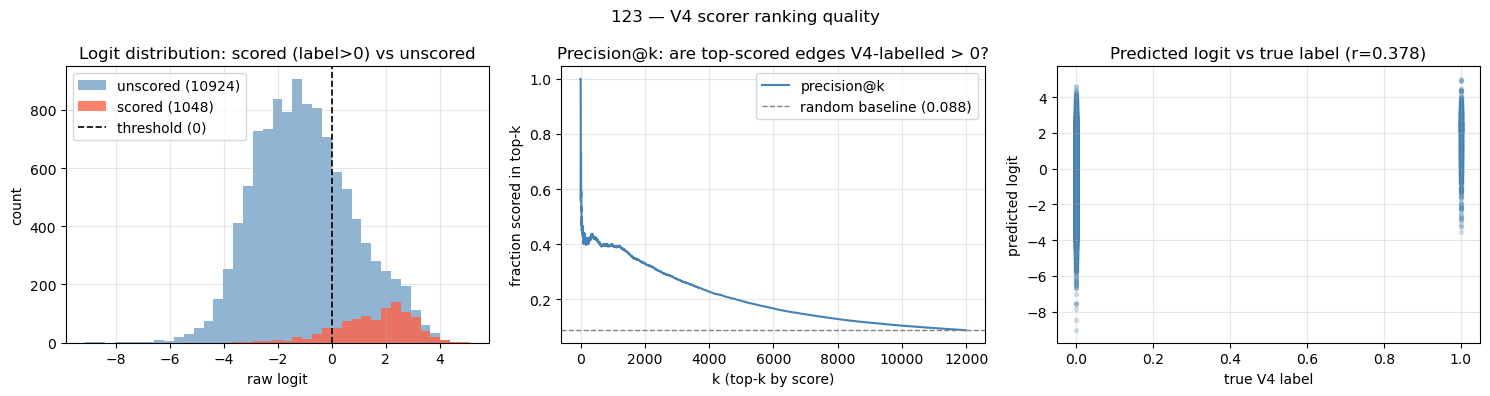

In [26]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

clear_output(wait=True)
plt.close("all")

lbl_bin = (labels_changed.cpu() > 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logit histogram: scored vs unscored
all_vals = np.concatenate([pos_logits, neg_logits])
lo, hi = all_vals.min() - 0.1, all_vals.max() + 0.1
bins = np.linspace(lo, hi, 40)

axes[0].hist(neg_logits, bins=bins, alpha=0.6, label=f'unscored ({len(neg_logits)})', color='steelblue')
axes[0].hist(pos_logits, bins=bins, alpha=0.8, label=f'scored ({len(pos_logits)})', color='tomato')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold (0)')
axes[0].set_xlabel('raw logit')
axes[0].set_ylabel('count')
axes[0].set_title('Logit distribution: scored (label>0) vs unscored')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision@k
sort_order_logit = all_logits.argsort(descending=True)
sorted_lbl_bin = lbl_bin[sort_order_logit].numpy().astype(float)
cum_pos = sorted_lbl_bin.cumsum()
rank = np.arange(1, len(sorted_lbl_bin) + 1)
random_base = lbl_bin.float().mean().item()

axes[1].plot(rank, cum_pos / rank, color='steelblue', linewidth=1.5, label='precision@k')
axes[1].axhline(random_base, color='grey', linestyle='--', linewidth=1, label=f'random baseline ({random_base:.3f})')
axes[1].set_xlabel('k (top-k by score)')
axes[1].set_ylabel('fraction scored in top-k')
axes[1].set_title('Precision@k: are top-scored edges V4-labelled > 0?')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Correlation
lbl_cont = labels_changed.detach().cpu().numpy().reshape(-1)
lg_np = all_logits.detach().cpu().numpy().reshape(-1)

print(lbl_cont.shape, lg_np.shape)

axes[2].scatter(lbl_cont, lg_np, alpha=0.2, s=8, color='steelblue')
axes[2].set_xlabel('true V4 label')
axes[2].set_ylabel('predicted logit')
axes[2].set_title('Predicted logit vs true continuous label')

if lbl_cont.std() > 1e-8 and lg_np.std() > 1e-8:
    corr = float(np.corrcoef(lbl_cont, lg_np)[0, 1])
    axes[2].set_title(f'Predicted logit vs true label (r={corr:.3f})')

axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 scorer ranking quality', fontsize=12)
plt.tight_layout()
plt.show()

AUC-ROC (scored vs unscored): 0.8642
Avg Precision:                0.3448  (random baseline = 0.0875)


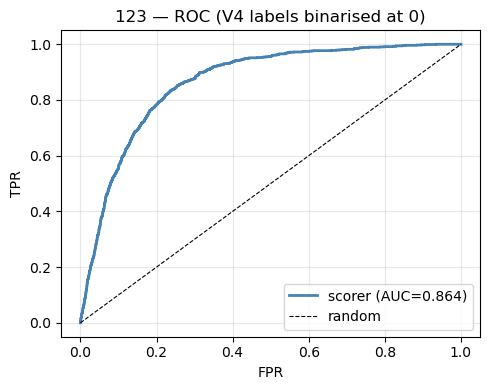

In [27]:
try:
    from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
    y_true  = lbl_bin.numpy().astype(int)
    y_score = all_logits.numpy()

    auc = roc_auc_score(y_true, y_score)
    ap  = average_precision_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    print(f'AUC-ROC (scored vs unscored): {auc:.4f}')
    print(f'Avg Precision:                {ap:.4f}  (random baseline = {random_base:.4f})')

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'scorer (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='random')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{123} — ROC (V4 labels binarised at 0)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('sklearn not available — skipping ROC')

---
## §7  Per-Node Analysis

For each node in the candidate set, we check:
- How many of its incident candidate edges have a non-zero V4 label?
- What is the mean predicted logit for scored vs unscored incident edges?
- A positive score gap means the scorer correctly prefers harmful incident edges for this node.

In [28]:
from collections import defaultdict

src_np    = src.cpu().numpy()
dst_np    = dst.cpu().numpy()
lbl_np_cn = labels_changed.cpu().numpy()
lg_np_cn  = all_logits.numpy()

node_to_cands = defaultdict(list)
for i in range(len(src_np)):
    u, v  = int(src_np[i]), int(dst_np[i])
    entry = (i, bool(lbl_np_cn[i] > 0), float(lbl_np_cn[i]), float(lg_np_cn[i]))
    node_to_cands[u].append(entry)
    node_to_cands[v].append(entry)

node_rows = []
for node, cands in node_to_cands.items():
    n_inc     = len(cands)
    n_pos_cn  = sum(1 for _, is_pos, _, _ in cands if is_pos)
    p_lgts    = [lg for _, is_pos, _, lg in cands if is_pos]
    n_lgts    = [lg for _, is_pos, _, lg in cands if not is_pos]
    node_rows.append({
        'node':           node,
        'degree':         int(degrees[node]),
        'n_incident':     n_inc,
        'n_scored':       n_pos_cn,
        'scored_rate':    n_pos_cn / n_inc,
        'mean_score_pos': float(np.mean(p_lgts)) if p_lgts else float('nan'),
        'mean_score_neg': float(np.mean(n_lgts)) if n_lgts else float('nan'),
    })

node_df = pd.DataFrame(node_rows)
print(f'Nodes with at least one incident candidate: {len(node_df)}')
print(f"Nodes with >= 1 scored candidate: {(node_df['n_scored'] > 0).sum()}")
display(node_df.describe())

Nodes with at least one incident candidate: 2810
Nodes with >= 1 scored candidate: 1148


,node,degree,n_incident,n_scored,scored_rate,mean_score_pos,mean_score_neg
count,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,1148.000000,2802.000000
mean,1404.500000,5.680427,8.520996,0.745907,0.088241,1.415080,-0.906850
std,811.321453,8.453357,2.858429,1.288084,0.150484,1.319064,1.388420
min,0.000000,1.000000,1.000000,0.000000,0.000000,-3.533580,-5.038487
25%,702.250000,2.000000,6.000000,0.000000,0.000000,0.634570,-1.842857
50%,1404.500000,4.000000,8.000000,0.000000,0.000000,1.547372,-1.098630
75%,2106.750000,7.000000,10.000000,1.000000,0.125000,2.369826,-0.147636
max,2809.000000,246.000000,18.000000,11.000000,1.000000,4.942510,4.494959


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


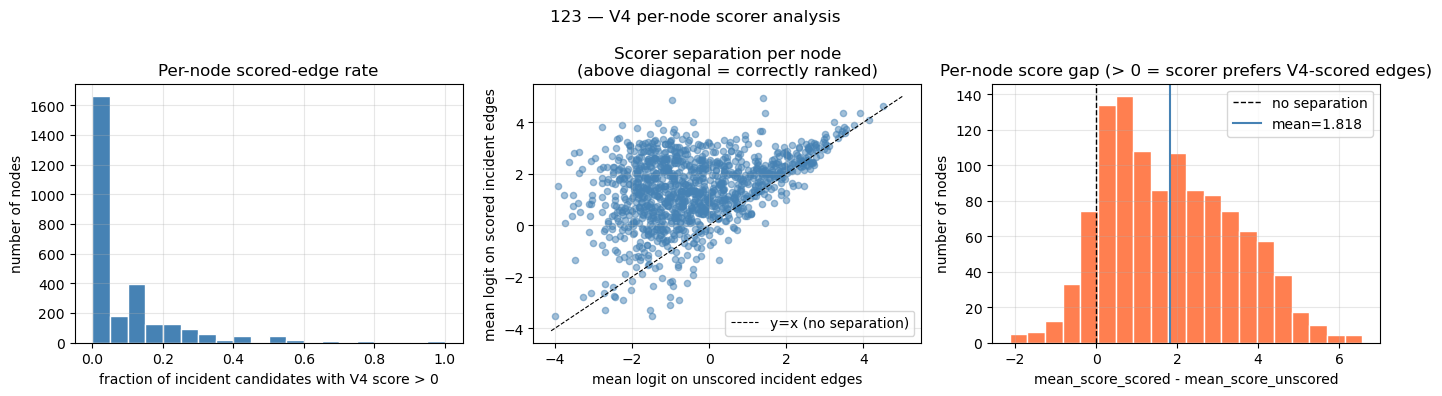

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(node_df['scored_rate'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('fraction of incident candidates with V4 score > 0')
axes[0].set_ylabel('number of nodes')
axes[0].set_title('Per-node scored-edge rate')
axes[0].grid(True, alpha=0.3)

has_both = node_df.dropna(subset=['mean_score_pos', 'mean_score_neg'])
axes[1].scatter(has_both['mean_score_neg'], has_both['mean_score_pos'],
                alpha=0.5, s=20, color='steelblue')
lo = min(has_both['mean_score_neg'].min(), has_both['mean_score_pos'].min()) - 0.1
hi = max(has_both['mean_score_neg'].max(), has_both['mean_score_pos'].max()) + 0.1
axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, label='y=x (no separation)')
axes[1].set_xlabel('mean logit on unscored incident edges')
axes[1].set_ylabel('mean logit on scored incident edges')
axes[1].set_title('Scorer separation per node\n(above diagonal = correctly ranked)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

hb = has_both.copy()
hb['score_gap'] = hb['mean_score_pos'] - hb['mean_score_neg']
axes[2].hist(hb['score_gap'], bins=20, color='coral', edgecolor='white')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='no separation')
axes[2].axvline(hb['score_gap'].mean(), color='steelblue', linestyle='-',
                linewidth=1.5, label=f"mean={hb['score_gap'].mean():.3f}")
axes[2].set_xlabel('mean_score_scored - mean_score_unscored')
axes[2].set_ylabel('number of nodes')
axes[2].set_title('Per-node score gap (> 0 = scorer prefers V4-scored edges)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 per-node scorer analysis', fontsize=12)
plt.tight_layout()
plt.show()